In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_curve, roc_auc_score
)

In [11]:
# Set Visual Style
sns.set(style="whitegrid")

# ==========================================
# Load Dataset
# ==========================================

data = pd.read_csv("diabetes.csv")

print("First Five Rows of Dataset:")
print(data.head())


First Five Rows of Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# ==========================================
# Data Preprocessing
# ==========================================
# Replace invalid zero values with median
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    data[col] = data[col].replace(0, np.nan)
    data[col].fillna(data[col].median(), inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_30452\2990743270.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


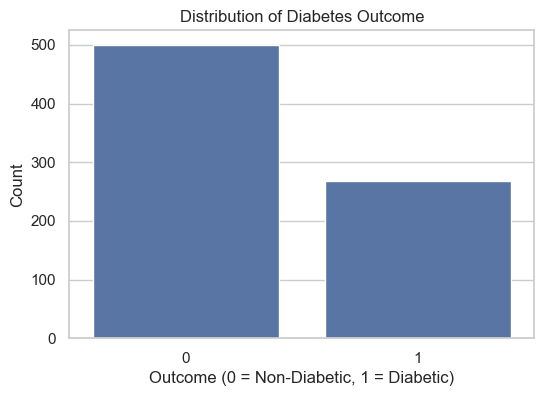

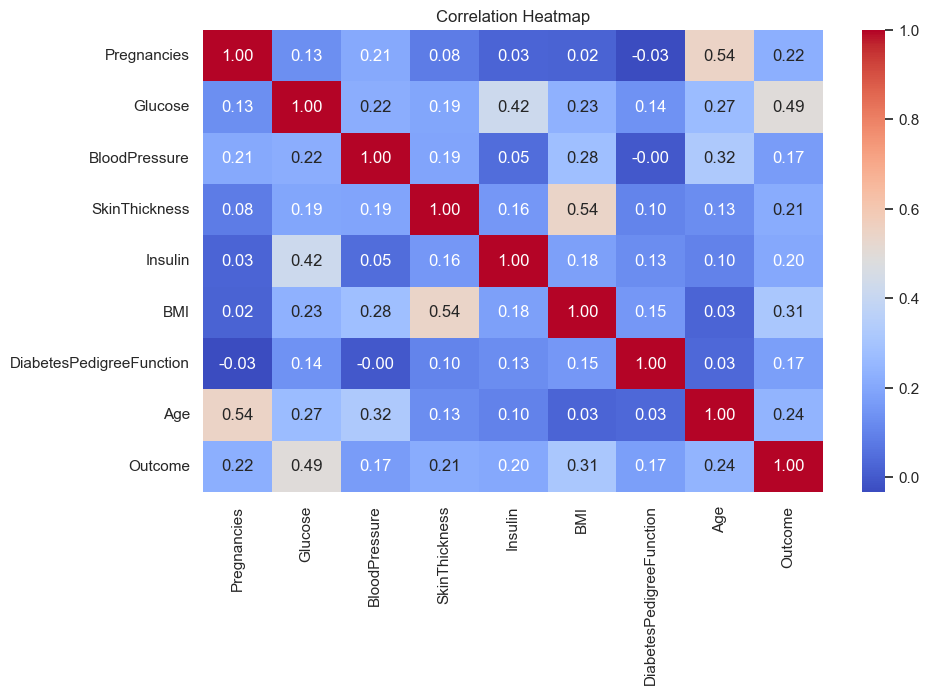

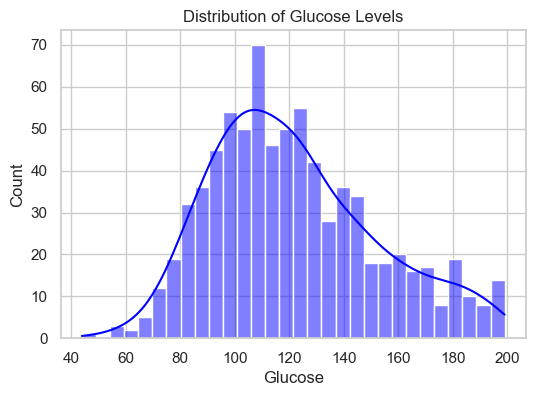

In [4]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

# Outcome Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data)
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Glucose Distribution
plt.figure(figsize=(6, 4))
sns.histplot(data['Glucose'], kde=True, bins=30, color='blue')
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.show()


In [5]:
# ==========================================
# Feature Selection
# ==========================================
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
# ==========================================
# Naïve Bayes Model Training
# ==========================================
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
# ==========================================
# Model Evaluation
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n===== Model Performance =====")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


===== Model Performance =====
Accuracy Score: 0.7013
ROC-AUC Score: 0.7646

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



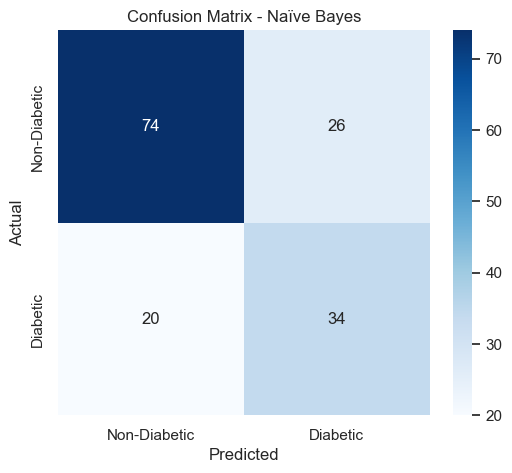

In [8]:
# ==========================================
# Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"])
plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

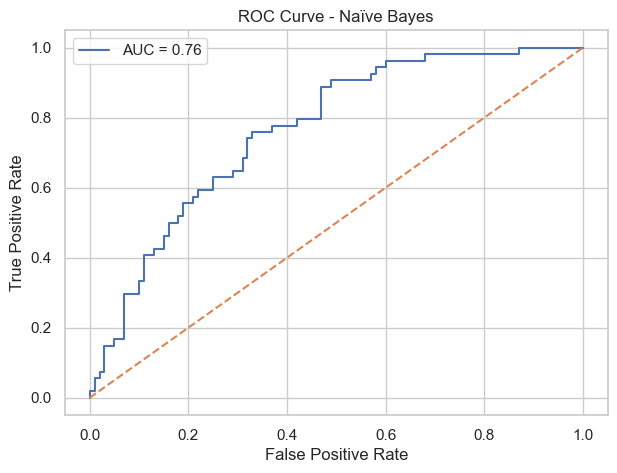

In [9]:
# ==========================================
# ROC Curve
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Naïve Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


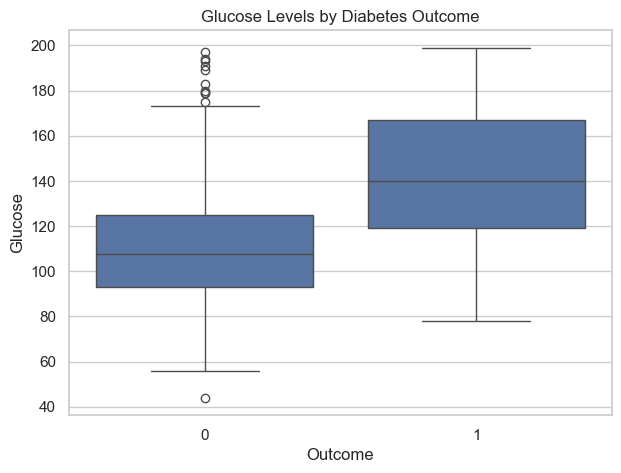

In [10]:
# ==========================================
# Feature Distribution by Outcome
# ==========================================
plt.figure(figsize=(7, 5))
sns.boxplot(x='Outcome', y='Glucose', data=data)
plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.show()